# 02 · Preprocesamiento

**Fase CRISP-DM:** preparación de los datos (limpieza e integración).

**Objetivo.** Aplicar, en orden, los criterios que fijó el EDA y dejar en `data/interim/` los datos limpios que usa el
feature engineering. Es el primer notebook que escribe en `data/`.

| | |
|---|---|
| **Entradas** | `data/raw/` (consultas y Kontur) y `resultados/01_eda/metricas.json` (para verificar coherencia) |
| **Salidas en `data/interim/`** | `consultas.parquet`, `usuarios_anomalos.parquet`, `area_estudio.geojson`, `consultas_limpias.parquet`, `semanas.parquet`, `kontur_h3r8.parquet`, `zonas.parquet` |
| **Resultados** | `resultados/02_preprocesamiento/` (flujo de limpieza, figuras y `metricas.json`) |

## 1. Configuración
Ubica la raíz del proyecto, borra las salidas que este notebook regenera e inicia el cronómetro.

In [1]:
import sys
from pathlib import Path

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(RAIZ))

In [2]:
from src.entorno import *  # noqa: F403
from src import espacial, features, lectura, limpieza

import geopandas as gpd
import h3

FASE = "02_preprocesamiento"
limpiar_salidas(FASE, [config.CONSULTAS, config.USUARIOS_ANOMALOS, config.AREA_ESTUDIO, config.CONSULTAS_LIMPIAS,
                       config.SEMANAS, config.KONTUR_H3, config.ZONAS])
M = {}
tiempo = cronometro()

## 2. Consolidación de las consultas
**Tipo de datos:** tabulares crudos (85 exportaciones semanales).

Se unen todas las exportaciones con un esquema común, su linaje (archivo, lote y codificación) y un orden estable,
para que re-ejecutar produzca exactamente el mismo archivo.

In [3]:
archivos = sorted(config.DATA_RAW.glob("*.csv"))
consultas, registro = lectura.leer_consultas(archivos)
assert consultas.height == registro["filas"].sum(), "La consolidación perdió filas"
consultas.write_parquet(config.CONSULTAS)
M.update({"csv_archivos": len(archivos), "consultas_crudas": consultas.height})
tiempo("consolidación")
print(f"{consultas.height:,} consultas de {len(archivos)} archivos → {config.CONSULTAS.name}")

⏱ consolidación: 7.6 s (acumulado 8 s)
1,927,675 consultas de 85 archivos → consultas.parquet


## 3. Usuarios anómalos
**Tipo de datos:** numéricos agregados por usuario.

Misma función que en el EDA: seis señales y marca con al menos `MIN_SENALES`. Se guarda la lista de usuarios marcados.

In [4]:
usuarios = limpieza.senales_usuario(consultas)
anomalos = usuarios.filter(pl.col("anomalo")).select("userID", "n_consultas", "n_senales")
anomalos.write_parquet(config.USUARIOS_ANOMALOS)
M["usuarios_anomalos"] = anomalos.height
tiempo("usuarios")
anomalos

⏱ usuarios: 8.7 s (acumulado 16 s)


userID,n_consultas,n_senales
str,u32,u32
"""634d8cba-2c48-4672-9fd6-76aa98…",59,2
"""703b4a7a-f753-4538-9ff7-5cb1f9…",174,2


## 4. Área de estudio
**Tipo de datos:** espaciales (polígono).

Envolvente de la componente H3 contigua principal de los orígenes válidos más un margen. Depende solo de dónde están
los orígenes, no del filtro de distancia.

In [5]:
AREA, celdas_componente = limpieza.area_estudio(consultas, anomalos["userID"])
gpd.GeoDataFrame({"regla": [f"componente H3 k={config.K_COMPONENTE} + {config.BUFFER_AREA_M} m"]},
                 geometry=[AREA], crs="EPSG:4326").to_file(config.AREA_ESTUDIO, driver="GeoJSON")
M.update({"area_km2": round(espacial.area_km2(AREA), 1), "area_celdas_componente": celdas_componente})
print({k: M[k] for k in ("area_km2", "area_celdas_componente")})

{'area_km2': 1505.7, 'area_celdas_componente': 919}


## 5. Filtrado de consultas
**Tipo de datos:** tabulares (reglas de exclusión en orden).

Orden: origen (0,0) → fuera de Bolivia → copia de duplicado exacto → origen fuera del área → distancia mayor a
`DIST_MAX_M` → usuario anómalo. A cada consulta válida se le asigna la zona H3 res 8 de su origen.

In [6]:
limpias, flujo = limpieza.filtrar_consultas(consultas, AREA, anomalos["userID"])
limpias.write_parquet(config.CONSULTAS_LIMPIAS)
M.update({"consultas_validas": limpias.height, "pct_consultas_validas": round(limpias.height / consultas.height * 100, 2)})
M.update({f"eliminadas_paso_{r['paso']}": r["filas_eliminadas"] for r in flujo.slice(1).iter_rows(named=True)})
tiempo("filtrado")
guardar_tabla(flujo, "flujo_limpieza", FASE)

⏱ filtrado: 11.7 s (acumulado 28 s)


paso,regla,filas_eliminadas,filas_despues,pct_conservado
i64,str,i64,i64,f64
0,"""consultas crudas""",0,1927675,100.0
1,"""origen (0,0)""",3,1927672,100.0
2,"""origen fuera de Bolivia""",9,1927663,99.999
3,"""copia de duplicado exacto""",60,1927603,99.996
4,"""origen fuera del área de estud…",2509,1925094,99.866
5,"""distancia > 50 km""",283,1924811,99.851
6,"""usuario anómalo""",233,1924578,99.839


PosixPath('/home/robvox/Desktop/trufi-data-science/resultados/02_preprocesamiento/figuras/flujo_limpieza.png')

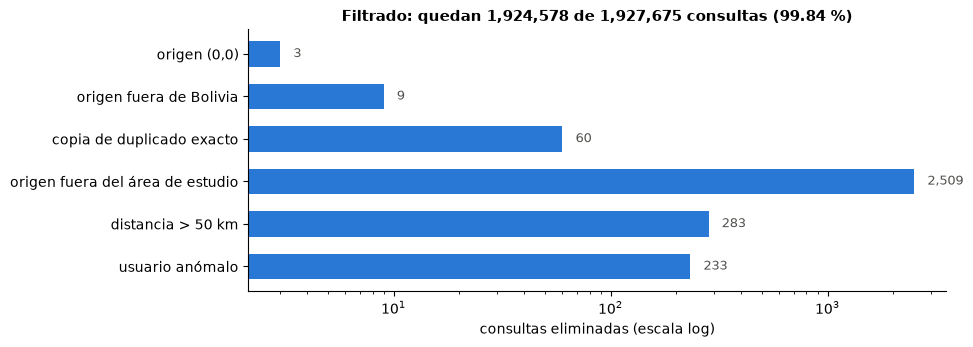

In [7]:
pasos = flujo.slice(1)
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.barh(pasos["regla"].to_list()[::-1], pasos["filas_eliminadas"].to_list()[::-1], color=AZUL, height=0.6)
for y, v in enumerate(pasos["filas_eliminadas"].to_list()[::-1]):
    ax.text(v * 1.15, y, f"{v:,}", va="center", color=TINTA, fontsize=9)
ax.set(xscale="log", xlabel="consultas eliminadas (escala log)",
       title=f"Filtrado: quedan {limpias.height:,} de {consultas.height:,} consultas ({M['pct_consultas_validas']} %)")
guardar_figura(fig, "flujo_limpieza", FASE)

## 6. Cobertura semanal y semanas observadas
**Tipo de datos:** temporales.

El hueco no se imputa. Se registra `W_obs`, las **semanas equivalentes observadas** (días con datos / 7): es el
divisor que convierte el conteo total esperado de cada zona en consultas esperadas por semana. También se guardan los
límites del hueco para la sensibilidad temporal.

In [8]:
semanas = limpieza.cobertura_semanal(limpias)
semanas.write_parquet(config.SEMANAS)
inicio_hueco, fin_hueco = limpieza.limites_hueco(semanas)
dias = limpias["ts"].dt.date()
M.update({"w_obs_semanas": round(semanas["dias_con_datos"].sum() / 7, 3), "semanas_observadas": int(semanas["observada"].sum()),
          "semanas_faltantes": int((~semanas["observada"]).sum()), "hueco_inicio": str(inicio_hueco),
          "hueco_fin": str(fin_hueco), "dias_antes_hueco": dias.filter(dias < inicio_hueco).n_unique(),
          "dias_despues_hueco": dias.filter(dias >= fin_hueco).n_unique()})
print({k: M[k] for k in ("w_obs_semanas", "semanas_observadas", "hueco_inicio", "hueco_fin", "dias_antes_hueco", "dias_despues_hueco")})

{'w_obs_semanas': 81.143, 'semanas_observadas': 84, 'hueco_inicio': '2024-03-11', 'hueco_fin': '2024-04-29', 'dias_antes_hueco': 538, 'dias_despues_hueco': 30}


## 7. Población Kontur
**Tipo de datos:** espaciales y numéricos.

Se guarda Kontur de todo Bolivia en res 8 (no solo el área): las coronas de población de las zonas del borde deben
contar también a los vecinos que quedan fuera del área.

In [9]:
kontur = lectura.leer_kontur(config.KONTUR_GPKG_GZ)
assert {h3.get_resolution(c) for c in kontur["h3_cell"].head(1000)} == {config.H3_RES}
kontur.write_parquet(config.KONTUR_H3)
M["kontur_celdas"] = kontur.height
tiempo("kontur")

⏱ kontur: 3.1 s (acumulado 31 s)


## 8. Tabla por zona
**Tipo de datos:** numéricos por zona (conteos y población).

Una fila por zona: las celdas Kontur del área más las celdas con consultas. Las zonas pobladas sin consultas entran
con `query_count = 0`; no se imputa nada. Se agregan los conteos antes y después del hueco y el centroide de cada zona.

In [10]:
zonas = features.tabla_por_zona(limpias, kontur, AREA)
zonas = (zonas.join(features.conteos_por_periodo(limpias, inicio_hueco, fin_hueco), on="h3_cell", how="left")
         .with_columns(pl.col("query_count_before_gap", "query_count_after_gap").fill_null(0)).sort("h3_cell"))
zonas.write_parquet(config.ZONAS)
q, pob = zonas["query_count"], zonas["population"]
M.update({"zonas": zonas.height, "zonas_con_consultas": int((q > 0).sum()),
          "zonas_pobladas_sin_consultas": int(((pob > 0) & (q == 0)).sum()),
          "zonas_pop_min": int((pob >= config.POP_MIN).sum()), "poblacion_zonas": int(pob.sum())})
print({k: M[k] for k in ("zonas", "zonas_con_consultas", "zonas_pobladas_sin_consultas", "zonas_pop_min", "poblacion_zonas")})

{'zonas': 1628, 'zonas_con_consultas': 1017, 'zonas_pobladas_sin_consultas': 611, 'zonas_pop_min': 1381, 'poblacion_zonas': 1226308}


⏱ tabla por zona: 2.0 s (acumulado 33 s)


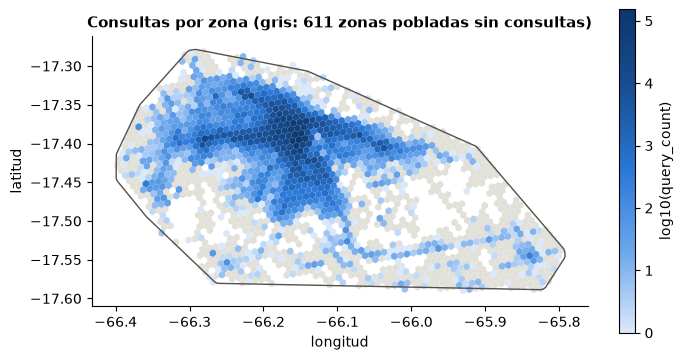

In [11]:
geo = espacial.geo_zonas(zonas.select("h3_cell", "query_count"))
fig, ax = plt.subplots(figsize=(8, 7))
geo[geo["query_count"] == 0].plot(ax=ax, color="#e1e0d9", edgecolor="none")
geo[geo["query_count"] > 0].assign(log_q=lambda d: np.log10(d["query_count"])).plot(
    ax=ax, column="log_q", cmap=SECUENCIAL, edgecolor="none", legend=True,
    legend_kwds={"label": "log10(query_count)", "shrink": 0.6})
gpd.GeoSeries([AREA], crs="EPSG:4326").boundary.plot(ax=ax, color=TINTA, lw=1)
ax.set(xlabel="longitud", ylabel="latitud",
       title=f"Consultas por zona (gris: {M['zonas_pobladas_sin_consultas']} zonas pobladas sin consultas)")
guardar_figura(fig, "consultas_por_zona", FASE)
tiempo("tabla por zona")

## 9. Verificaciones

### 9.1 Integridad
El flujo cuadra con el total, el objetivo suma las consultas válidas y no hay nulos ni zonas repetidas.

In [12]:
assert flujo["filas_eliminadas"].sum() + limpias.height == consultas.height
assert zonas["query_count"].sum() == limpias.height, "El objetivo no suma las consultas válidas"
assert (zonas["query_count_before_gap"] + zonas["query_count_after_gap"] <= zonas["query_count"]).all()
assert zonas["h3_cell"].is_unique().all() and zonas.null_count().sum_horizontal().item() == 0
assert limpias["h3_origin"].null_count() == 0
print("Integridad correcta")

Integridad correcta


### 9.2 Coherencia con el EDA
Se aplicaron las mismas reglas que en el EDA, así que las cifras compartidas deben coincidir con su `metricas.json`.

In [13]:
eda = leer_metricas("01_eda")
assert M["consultas_validas"] == eda["consultas_validas"], "Consultas válidas distintas del EDA"
assert M["area_km2"] == eda["area_km2"], "Área distinta del EDA"
assert M["zonas"] == eda["zonas_area"], "Número de zonas distinto del EDA"
assert M["zonas_pop_min"] == eda["zonas_pop_min"], "Zonas con población mínima distintas del EDA"
assert M["usuarios_anomalos"] == eda["usuarios_anomalos"], "Usuarios anómalos distintos del EDA"
print("Coincide con resultados/01_eda/metricas.json")

Coincide con resultados/01_eda/metricas.json


### 9.3 Sin usuarios anómalos
Ninguna consulta válida pertenece a un usuario marcado.

In [14]:
assert not limpias["userID"].is_in(anomalos["userID"].implode()).any(), "Quedan usuarios anómalos"
print("Sin usuarios anómalos en consultas_limpias.parquet")

Sin usuarios anómalos en consultas_limpias.parquet


## 10. Cierre
`data/interim/` queda listo para el feature engineering, que parte de `zonas.parquet`, `kontur_h3r8.parquet`,
`area_estudio.geojson` y el municipio de origen de `consultas_limpias.parquet`.

In [15]:
M.update({"semilla": config.SEMILLA, "dist_max_m": config.DIST_MAX_M, "buffer_area_m": config.BUFFER_AREA_M,
          "k_componente": config.K_COMPONENTE, "pop_min": config.POP_MIN})
ruta = guardar_metricas(FASE, M)
tiempo("cierre")
print(f"{len(M)} métricas → {ruta.relative_to(config.RAIZ)}")

⏱ cierre: 0.4 s (acumulado 34 s)
31 métricas → resultados/02_preprocesamiento/metricas.json
